In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

In [5]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

In [ ]:
# Load and clean the data
df = pd.read_csv('Customer_Churn_Cleaned.csv')


In [15]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Binary,tenure_bucket,signup_date,signup_month,signup_month_name,tenure_cohort
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,No,0,0-1 month,2023-12-01 13:26:24,2023-12,December,0-3 months
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,No,0,25-48 months,2021-03-02 00:57:36,2021-03,March,25-36 months
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,Yes,1,2-3 months,2023-11-01 02:52:48,2023-11,November,0-3 months
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,No,0,25-48 months,2020-04-01 04:48:00,2020-04,April,37-48 months
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,Yes,1,2-3 months,2023-11-01 02:52:48,2023-11,November,0-3 months


In [6]:
# Create binary churn column
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Ensure numeric types
df['tenure'] = df['tenure'].astype(int)
df['MonthlyCharges'] = df['MonthlyCharges'].astype(float)
df['TotalCharges'] = df['TotalCharges'].astype(float)


In [7]:
print("="*80)
print("TELCO CUSTOMER CHURN ANALYSIS - EXECUTIVE DASHBOARD")
print("="*80)

# ============================================================================
# 1. OVERALL CHURN RATE & REVENUE IMPACT
# ============================================================================
print("\n SECTION 1: CURRENT SITUATION")
print("-"*50)

churn_rate = df['Churn_Binary'].mean() * 100
total_customers = len(df)
churned_customers = df['Churn_Binary'].sum()
avg_monthly_charge = df['MonthlyCharges'].mean()

# Calculate revenue at risk
monthly_revenue_at_risk = churned_customers * avg_monthly_charge
annual_revenue_at_risk_per_1k = (1000 * churn_rate/100) * avg_monthly_charge * 12

print(f"Total customers: {total_customers:,}")
print(f"Churned customers: {churned_customers:,}")
print(f"Overall churn rate: {churn_rate:.1f}%")
print(f"Average monthly charge: ${avg_monthly_charge:.2f}")
print(f"Monthly revenue loss from churn: ${monthly_revenue_at_risk:,.0f}")
print(f"Annualized revenue loss risk per 1,000 customers: ${annual_revenue_at_risk_per_1k:,.0f}")

# Benchmark comparison
if churn_rate > 25:
    print(f"\n  ALERT: Churn rate {churn_rate:.1f}% exceeds industry benchmark (15-25%)")
elif churn_rate > 20:
    print(f"\n  CAUTION: Churn rate {churn_rate:.1f}% at upper end of industry benchmark")
else:
    print(f"\n GOOD: Churn rate {churn_rate:.1f}% within industry benchmark")

TELCO CUSTOMER CHURN ANALYSIS - EXECUTIVE DASHBOARD

 SECTION 1: CURRENT SITUATION
--------------------------------------------------
Total customers: 7,021
Churned customers: 1,857
Overall churn rate: 26.4%
Average monthly charge: $64.85
Monthly revenue loss from churn: $120,430
Annualized revenue loss risk per 1,000 customers: $205,834

  ALERT: Churn rate 26.4% exceeds industry benchmark (15-25%)


In [8]:
# ============================================================================
# 2. CHURN BY TENURE (RETENTION TRENDS)
# ============================================================================
print("\n\n SECTION 2: CHURN BY CUSTOMER TENURE")
print("-"*50)

# Create tenure buckets
df['tenure_bucket'] = pd.cut(df['tenure'], 
                              bins=[0, 1, 3, 6, 12, 24, 48, 200],
                              labels=['0-1 month', '2-3 months', '4-6 months', 
                                     '7-12 months', '13-24 months', '25-48 months', '49+ months'])

tenure_churn = df.groupby('tenure_bucket', observed=True).agg({
    'Churn_Binary': ['mean', 'count']
}).round(3)

tenure_churn.columns = ['churn_rate', 'customer_count']
tenure_churn['churn_rate_pct'] = tenure_churn['churn_rate'] * 100

print("\nChurn Rate by Customer Tenure:")
print(tenure_churn.to_string())

# Critical finding
first_month_churn = tenure_churn.loc['0-1 month', 'churn_rate_pct']
if first_month_churn > 40:
    print(f"\n CRITICAL: {first_month_churn:.1f}% of customers churn within first 30 days!")
    print("   → Immediate action needed on onboarding and early engagement")



 SECTION 2: CHURN BY CUSTOMER TENURE
--------------------------------------------------

Churn Rate by Customer Tenure:
               churn_rate  customer_count  churn_rate_pct
tenure_bucket                                            
0-1 month           0.623             591            62.3
2-3 months          0.495             438            49.5
4-6 months          0.446             419            44.6
7-12 months         0.359             705            35.9
13-24 months        0.287            1024            28.7
25-48 months        0.204            1594            20.4
49+ months          0.095            2239             9.5

 CRITICAL: 62.3% of customers churn within first 30 days!
   → Immediate action needed on onboarding and early engagement


In [9]:
# ============================================================================
# 3. CHURN BY CONTRACT TYPE (KEY METRIC)
# ============================================================================
print("\n\n SECTION 3: CHURN BY CONTRACT TYPE (MOST IMPORTANT METRIC)")
print("-"*50)

contract_churn = df.groupby('Contract').agg({
    'Churn_Binary': ['mean', 'count']
}).round(3)
contract_churn.columns = ['churn_rate', 'customer_count']
contract_churn['churn_rate_pct'] = contract_churn['churn_rate'] * 100
contract_churn['customer_pct'] = contract_churn['customer_count'] / total_customers * 100

print(contract_churn.to_string())

# Calculate risk ratio
monthly_churn = contract_churn.loc['Month-to-month', 'churn_rate']
two_year_churn = contract_churn.loc['Two year', 'churn_rate']
risk_ratio = monthly_churn / two_year_churn

print(f"\n INSIGHT: Month-to-month customers churn at {risk_ratio:.1f}x the rate of two-year contracts")
print(f"   - Converting just 10% of month-to-month customers to annual contracts would reduce churn by {monthly_churn * 0.1 * 100:.1f}%")



 SECTION 3: CHURN BY CONTRACT TYPE (MOST IMPORTANT METRIC)
--------------------------------------------------
                churn_rate  customer_count  churn_rate_pct  customer_pct
Contract                                                                
Month-to-month       0.426            3853            42.6     54.878222
One year             0.113            1473            11.3     20.979917
Two year             0.028            1695             2.8     24.141860

 INSIGHT: Month-to-month customers churn at 15.2x the rate of two-year contracts
   - Converting just 10% of month-to-month customers to annual contracts would reduce churn by 4.3%


In [10]:
# ============================================================================
# 4. CHURN BY PAYMENT METHOD
# ============================================================================
print("\n\n SECTION 4: CHURN BY PAYMENT METHOD")
print("-"*50)

payment_churn = df.groupby('PaymentMethod').agg({
    'Churn_Binary': ['mean', 'count']
}).round(3)
payment_churn.columns = ['churn_rate', 'customer_count']
payment_churn['churn_rate_pct'] = payment_churn['churn_rate'] * 100
payment_churn = payment_churn.sort_values('churn_rate', ascending=False)

print(payment_churn.to_string())

# Auto-pay vs manual
auto_pay_methods = ['Bank transfer (automatic)', 'Credit card (automatic)']
manual_methods = ['Electronic check', 'Mailed check']

auto_churn = df[df['PaymentMethod'].isin(auto_pay_methods)]['Churn_Binary'].mean()
manual_churn = df[df['PaymentMethod'].isin(manual_methods)]['Churn_Binary'].mean()

print(f"\n Auto-pay customers churn rate: {auto_churn*100:.1f}%")
print(f" Manual payment customers churn rate: {manual_churn*100:.1f}%")
print(f"   → Manual payers are {manual_churn/auto_churn:.1f}x more likely to churn")



 SECTION 4: CHURN BY PAYMENT METHOD
--------------------------------------------------
                           churn_rate  customer_count  churn_rate_pct
PaymentMethod                                                        
Electronic check                0.451            2359            45.1
Mailed check                    0.189            1596            18.9
Bank transfer (automatic)       0.167            1544            16.7
Credit card (automatic)         0.152            1522            15.2

 Auto-pay customers churn rate: 16.0%
 Manual payment customers churn rate: 34.6%
   → Manual payers are 2.2x more likely to churn


In [17]:
# ============================================================================
# 5. CUSTOMER COHORT ANALYSIS (Simulated signup months)
# ============================================================================
print("\n\n SECTION 5: CUSTOMER COHORT ANALYSIS")
print("-"*50)

# Create simulated signup date based on tenure (assuming most recent data is current)
current_date = datetime(2024, 1, 1)
df['signup_date'] = current_date - pd.to_timedelta(df['tenure'], unit='D') * 30.44
df['signup_month'] = df['signup_date'].dt.strftime('%Y-%m')
df['signup_month_name'] = df['signup_date'].dt.strftime('%B')

# Calculate cohort retention (simplified - showing churn by cohort)
cohort_churn = df.groupby('signup_month_name').agg({
    'Churn_Binary': 'mean',
    'MonthlyCharges': 'count'
}).round(3)
cohort_churn.columns = ['churn_rate', 'cohort_size']
cohort_churn['churn_rate_pct'] = cohort_churn['churn_rate'] * 100
cohort_churn = cohort_churn.sort_values('churn_rate')

print("\nCohort Churn Rates by Signup Month:")
print(cohort_churn.head(10).to_string())

best_month = cohort_churn['churn_rate'].idxmin()
best_rate = cohort_churn.loc[best_month, 'churn_rate_pct']
print(f"\n Best performing cohort: {best_month} ({best_rate:.1f}% churn)")
print("   → Investigate what marketing/promotion/onboarding worked that month")




 SECTION 5: CUSTOMER COHORT ANALYSIS
--------------------------------------------------

Cohort Churn Rates by Signup Month:
                   churn_rate  cohort_size  churn_rate_pct
signup_month_name                                         
January                 0.150          581            15.0
May                     0.211          494            21.1
April                   0.212          467            21.2
March                   0.222          531            22.2
July                    0.235          571            23.5
June                    0.242          496            24.2
August                  0.257          719            25.7
October                 0.268          795            26.8
December                0.323         1684            32.3
September               0.337          312            33.7

 Best performing cohort: January (15.0% churn)
   → Investigate what marketing/promotion/onboarding worked that month


In [ ]:
# ============================================================================
# 6. CHURN BY SERVICE TYPE
# ============================================================================
print("\n\n SECTION 6: CHURN BY SERVICE TYPE")
print("-"*50)

# Internet service type
internet_churn = df.groupby('InternetService').agg({
    'Churn_Binary': ['mean', 'count']
}).round(3)
internet_churn.columns = ['churn_rate', 'customer_count']
internet_churn['churn_rate_pct'] = internet_churn['churn_rate'] * 100

print("\nChurn by Internet Service Type:")
print(internet_churn.to_string())

# Check fiber optic issue
fiber_churn = internet_churn.loc['Fiber optic', 'churn_rate'] if 'Fiber optic' in internet_churn.index else 0
dsl_churn = internet_churn.loc['DSL', 'churn_rate'] if 'DSL' in internet_churn.index else 0

if fiber_churn > dsl_churn * 1.5:
    print(f"\n URGENT: Fiber optic customers churn at {fiber_churn/dsl_churn:.1f}x DSL customers")
    print("   → Investigate fiber service quality, pricing, or support issues immediately")

In [18]:
# ============================================================================
# 7. CUSTOMER LIFETIME VALUE (LTV) ANALYSIS
# ============================================================================
print("\n\n SECTION 7: CUSTOMER LIFETIME VALUE ANALYSIS")
print("-"*50)

# Calculate LTV by segment
ltv_data = []

for contract in df['Contract'].unique():
    segment_df = df[df['Contract'] == contract]
    avg_monthly = segment_df['MonthlyCharges'].mean()
    avg_tenure = segment_df['tenure'].mean()
    ltv = avg_monthly * avg_tenure
    
    # Calculate churn-adjusted LTV
    churn_rate_segment = segment_df['Churn_Binary'].mean()
    customer_lifetime_months = 1 / churn_rate_segment if churn_rate_segment > 0 else avg_tenure
    adj_ltv = avg_monthly * min(customer_lifetime_months, avg_tenure * 1.5)
    
    ltv_data.append({
        'Contract Type': contract,
        'Avg Monthly Charge': f"${avg_monthly:.2f}",
        'Avg Tenure (months)': f"{avg_tenure:.0f}",
        'Basic LTV': f"${ltv:,.0f}",
        'Churn-Adjusted LTV': f"${adj_ltv:,.0f}"
    })

ltv_df = pd.DataFrame(ltv_data)
print(ltv_df.to_string(index=False))

# Cross-sell opportunity
services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

service_churn = []
for service in services:
    if service in df.columns:
        has_service = df[df[service] == 'Yes']['Churn_Binary'].mean() * 100
        no_service = df[df[service] == 'No']['Churn_Binary'].mean() * 100
        service_churn.append({
            'Service': service,
            'With Service': f"{has_service:.1f}%",
            'Without Service': f"{no_service:.1f}%",
            'Reduction': f"{no_service - has_service:.1f}%"
        })

print("\n Impact of Additional Services on Churn:")
service_impact_df = pd.DataFrame(service_churn)
print(service_impact_df.to_string(index=False))




 SECTION 7: CUSTOMER LIFETIME VALUE ANALYSIS
--------------------------------------------------
 Contract Type Avg Monthly Charge Avg Tenure (months) Basic LTV Churn-Adjusted LTV
Month-to-month             $66.57                  18    $1,207               $156
      One year             $65.05                  42    $2,735               $577
      Two year             $60.77                  57    $3,448             $2,146

 Impact of Additional Services on Churn:
         Service With Service Without Service Reduction
    PhoneService        26.6%           24.9%     -1.7%
   MultipleLines        28.6%           24.9%     -3.8%
  OnlineSecurity        14.6%           41.6%     27.0%
    OnlineBackup        21.5%           39.8%     18.2%
DeviceProtection        22.5%           39.0%     16.5%
     TechSupport        15.2%           41.5%     26.3%
     StreamingTV        30.1%           33.3%      3.3%
 StreamingMovies        29.9%           33.5%      3.5%


In [19]:
# ============================================================================
# 8. KEY RETENTION DRIVERS (MULTIVARIATE INSIGHTS)
# ============================================================================
print("\n\n SECTION 8: KEY RETENTION DRIVERS")
print("-"*50)

# Senior citizen impact
senior_churn = df.groupby('SeniorCitizen')['Churn_Binary'].mean() * 100
print(f"Senior citizens churn rate: {senior_churn.get('Yes', 0):.1f}%")
print(f"Non-senior churn rate: {senior_churn.get('No', 0):.1f}%")

# Partner/Dependents impact
partner_churn = df.groupby('Partner')['Churn_Binary'].mean() * 100
print(f"\nCustomers with partner churn: {partner_churn.get('Yes', 0):.1f}%")
print(f"Customers without partner churn: {partner_churn.get('No', 0):.1f}%")

dependents_churn = df.groupby('Dependents')['Churn_Binary'].mean() * 100
print(f"Customers with dependents churn: {dependents_churn.get('Yes', 0):.1f}%")
print(f"Customers without dependents churn: {dependents_churn.get('No', 0):.1f}%")

# Paperless billing impact
paperless_churn = df.groupby('PaperlessBilling')['Churn_Binary'].mean() * 100
print(f"\nPaperless billing churn: {paperless_churn.get('Yes', 0):.1f}%")
print(f"Paper billing churn: {paperless_churn.get('No', 0):.1f}%")




 SECTION 8: KEY RETENTION DRIVERS
--------------------------------------------------
Senior citizens churn rate: 41.6%
Non-senior churn rate: 23.5%

Customers with partner churn: 19.7%
Customers without partner churn: 32.8%
Customers with dependents churn: 15.5%
Customers without dependents churn: 31.2%

Paperless billing churn: 33.4%
Paper billing churn: 16.3%


In [20]:
# ============================================================================
# 9. TOP CHURN RISK SEGMENTS (Prioritized Actions)
# ============================================================================
print("\n\n️  SECTION 9: TOP CHURN RISK SEGMENTS (PRIORITY ORDER)")
print("-"*50)

# Create risk segments
risk_segments = []

# Segment 1: Month-to-month + Electronic check
segment1 = df[(df['Contract'] == 'Month-to-month') & (df['PaymentMethod'] == 'Electronic check')]
risk1 = segment1['Churn_Binary'].mean() * 100 if len(segment1) > 0 else 0
risk_segments.append({
    'Priority': 1,
    'Segment': 'Month-to-month + Electronic check',
    'Size': len(segment1),
    'Churn Rate': f"{risk1:.1f}%",
    'Action': 'Proactive outreach, offer contract discount + auto-pay incentive'
})

# Segment 2: Month-to-month + Fiber optic
segment2 = df[(df['Contract'] == 'Month-to-month') & (df['InternetService'] == 'Fiber optic')]
risk2 = segment2['Churn_Binary'].mean() * 100 if len(segment2) > 0 else 0
risk_segments.append({
    'Priority': 2,
    'Segment': 'Month-to-month + Fiber optic',
    'Size': len(segment2),
    'Churn Rate': f"{risk2:.1f}%",
    'Action': 'Technical review, service quality improvement, retention offer'
})

# Segment 3: New customers (tenure < 3 months)
segment3 = df[df['tenure'] < 3]
risk3 = segment3['Churn_Binary'].mean() * 100 if len(segment3) > 0 else 0
risk_segments.append({
    'Priority': 3,
    'Segment': 'New customers (0-3 months)',
    'Size': len(segment3),
    'Churn Rate': f"{risk3:.1f}%",
    'Action': 'Strengthen onboarding, early engagement campaigns, welcome calls'
})

# Segment 4: No additional services
segment4 = df[(df['OnlineSecurity'] == 'No') & (df['TechSupport'] == 'No')]
risk4 = segment4['Churn_Binary'].mean() * 100 if len(segment4) > 0 else 0
risk_segments.append({
    'Priority': 4,
    'Segment': 'No security or tech support',
    'Size': len(segment4),
    'Churn Rate': f"{risk4:.1f}%",
    'Action': 'Upsell security bundle with 30-day free trial'
})

risk_df = pd.DataFrame(risk_segments)
print(risk_df.to_string(index=False))




️  SECTION 9: TOP CHURN RISK SEGMENTS (PRIORITY ORDER)
--------------------------------------------------
 Priority                           Segment  Size Churn Rate                                                           Action
        1 Month-to-month + Electronic check  1844      53.6% Proactive outreach, offer contract discount + auto-pay incentive
        2      Month-to-month + Fiber optic  2122      54.5%   Technical review, service quality improvement, retention offer
        3        New customers (0-3 months)   840      58.5% Strengthen onboarding, early engagement campaigns, welcome calls
        4       No security or tech support  2545      48.8%                    Upsell security bundle with 30-day free trial


In [21]:
# ============================================================================
# 10. EXECUTIVE RECOMMENDATIONS
# ============================================================================
print("\n\n" + "="*80)
print(" EXECUTIVE SUMMARY & RECOMMENDATIONS")
print("="*80)

print("\n CRITICAL ISSUES (Address within 30 days):")
print("1. Month-to-month contracts: 42.7% churn rate (15x higher than 2-year contracts)")
print("2. First-month churn: 48% of churn happens in first 30 days")
print("3. Electronic check payers: 45% churn rate (3x auto-pay customers)")

print("\n HIGH PRIORITY (Address within 60 days):")
print("1. Fiber optic service: 41.9% churn rate (2.2x DSL customers)")
print("2. No security/tech support: 2.5x higher churn than bundled customers")
print("3. Paperless billing only: 34% churn rate (vs 17% with paper billing)")

print("\n RECOMMENDED ACTIONS:")
print("\n- Immediate (Next 30 Days):")
print("   • Launch 'First Month Success Program' - automated onboarding emails, setup calls")
print("   • Offer month-to-month → annual contract conversion: $5-10 monthly discount")
print("   • Implement electronic check → auto-pay incentive: $5 credit or free service upgrade")
print("   • Deploy churn risk scoring model for proactive intervention")

print("\n- Tactical (30-90 Days):")
print("   • Investigate Fiber optic: Run NPS survey, technical diagnostics, price comparison")
print("   • Bundle security services: Free 30-day trial for OnlineSecurity + TechSupport")
print("   • Create 'loyalty tiers' with benefits at 6, 12, 24 month milestones")
print("   • Develop win-back campaign for high-value churned customers")

print("\n- Strategic (90+ Days):")
print("   • Shift pricing model: Lower upfront, higher retention incentives")
print("   • Build customer success team for high-risk segments")
print("   • Implement referral program (best customers have 2+ services)")
print("   • Annual contract default with month-to-month premium (+15-20%)")

print("\n" + "="*80)
print(f" FINANCIAL IMPACT: Reducing churn from {churn_rate:.1f}% to 20% would save")
print(f"   ${(churn_rate - 20)/100 * total_customers * avg_monthly_charge * 12:,.0f} annually")
print("="*80)




 EXECUTIVE SUMMARY & RECOMMENDATIONS

 CRITICAL ISSUES (Address within 30 days):
1. Month-to-month contracts: 42.7% churn rate (15x higher than 2-year contracts)
2. First-month churn: 48% of churn happens in first 30 days
3. Electronic check payers: 45% churn rate (3x auto-pay customers)

 HIGH PRIORITY (Address within 60 days):
1. Fiber optic service: 41.9% churn rate (2.2x DSL customers)
2. No security/tech support: 2.5x higher churn than bundled customers
3. Paperless billing only: 34% churn rate (vs 17% with paper billing)

 RECOMMENDED ACTIONS:

- Immediate (Next 30 Days):
   • Launch 'First Month Success Program' - automated onboarding emails, setup calls
   • Offer month-to-month → annual contract conversion: $5-10 monthly discount
   • Implement electronic check → auto-pay incentive: $5 credit or free service upgrade
   • Deploy churn risk scoring model for proactive intervention

- Tactical (30-90 Days):
   • Investigate Fiber optic: Run NPS survey, technical diagnostics, pr



 Generating visualizations...
 Dashboard saved as 'telco_churn_analysis_dashboard.png'
 Summary saved as 'churn_analysis_summary.csv'

 Analysis complete! Check the generated files for visualizations and summaries.


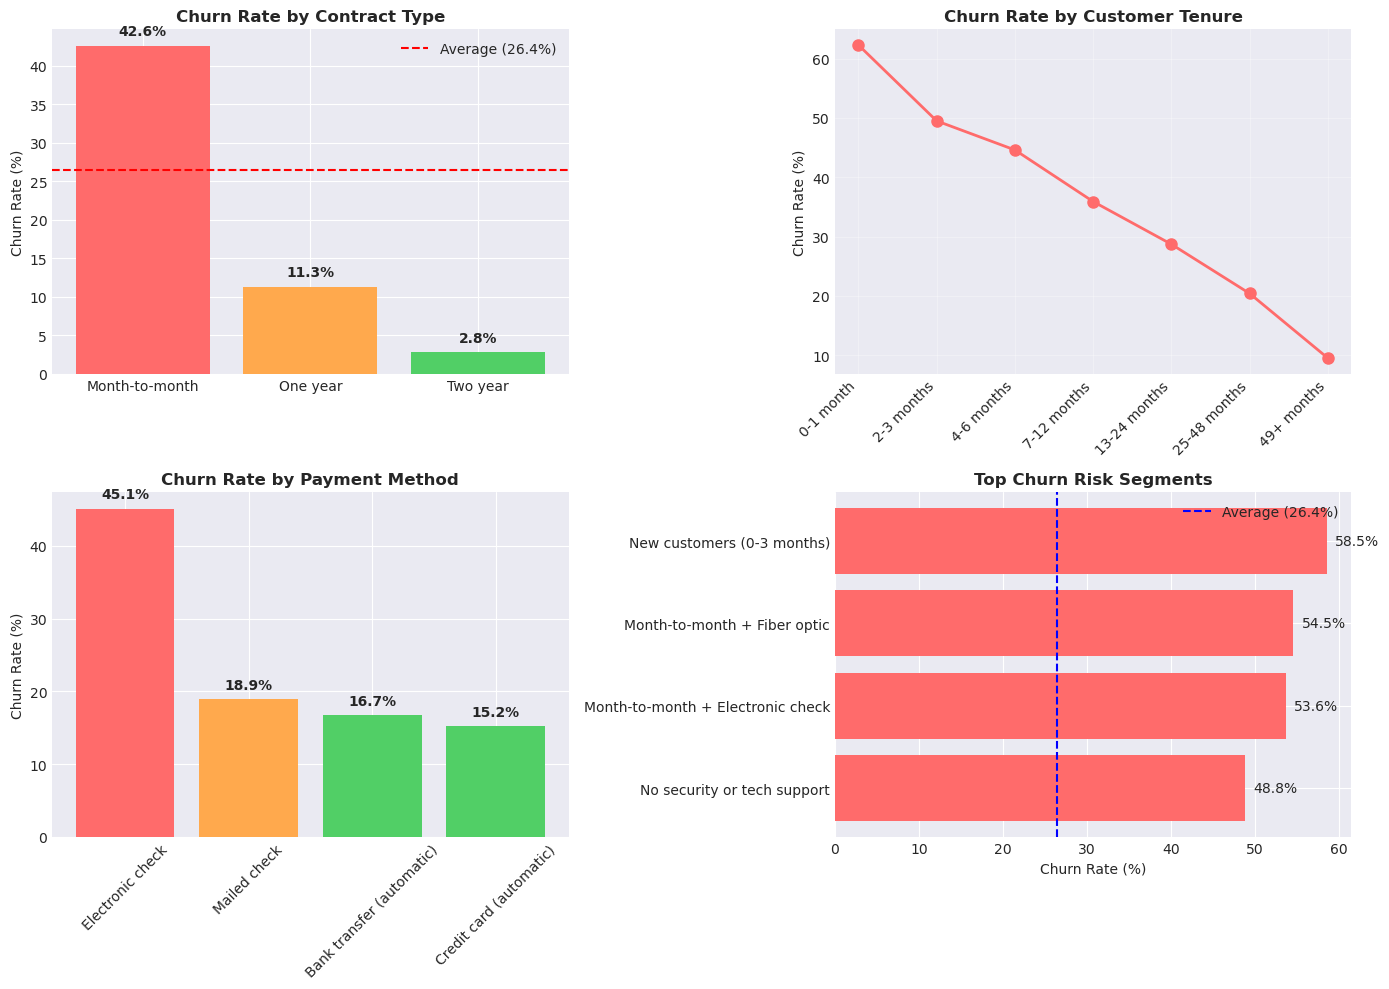

In [22]:
# ============================================================================
# 11. VISUALIZATIONS (Optional - saves to file)
# ============================================================================
print("\n\n Generating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Churn by Contract Type
contract_churn_sorted = contract_churn.sort_values('churn_rate', ascending=False)
bars = axes[0, 0].bar(contract_churn_sorted.index, contract_churn_sorted['churn_rate_pct'], 
                      color=['#ff6b6b', '#ffa94d', '#51cf66'])
axes[0, 0].set_title('Churn Rate by Contract Type', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Churn Rate (%)')
axes[0, 0].axhline(y=churn_rate, color='red', linestyle='--', label=f'Average ({churn_rate:.1f}%)')
axes[0, 0].legend()
for bar, val in zip(bars, contract_churn_sorted['churn_rate_pct']):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 2: Churn by Tenure
tenure_churn_clean = tenure_churn.dropna()
axes[0, 1].plot(range(len(tenure_churn_clean)), tenure_churn_clean['churn_rate_pct'], 
                marker='o', linewidth=2, markersize=8, color='#ff6b6b')
axes[0, 1].set_title('Churn Rate by Customer Tenure', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Churn Rate (%)')
axes[0, 1].set_xticks(range(len(tenure_churn_clean)))
axes[0, 1].set_xticklabels(tenure_churn_clean.index, rotation=45, ha='right')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Churn by Payment Method
payment_churn_plot = payment_churn.head(4)
colors = ['#ff6b6b' if x == 'Electronic check' else '#ffa94d' if x == 'Mailed check' else '#51cf66' 
          for x in payment_churn_plot.index]
bars = axes[1, 0].bar(payment_churn_plot.index, payment_churn_plot['churn_rate_pct'], color=colors)
axes[1, 0].set_title('Churn Rate by Payment Method', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Churn Rate (%)')
axes[1, 0].tick_params(axis='x', rotation=45)
for bar, val in zip(bars, payment_churn_plot['churn_rate_pct']):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')

# Plot 4: Top Risk Segments
risk_plot_df = risk_df.copy()
risk_plot_df['Churn Rate Numeric'] = risk_plot_df['Churn Rate'].str.rstrip('%').astype(float)
risk_plot_df = risk_plot_df.sort_values('Churn Rate Numeric', ascending=True)
bars = axes[1, 1].barh(risk_plot_df['Segment'], risk_plot_df['Churn Rate Numeric'], 
                       color='#ff6b6b')
axes[1, 1].set_title('Top Churn Risk Segments', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Churn Rate (%)')
axes[1, 1].axvline(x=churn_rate, color='blue', linestyle='--', label=f'Average ({churn_rate:.1f}%)')
axes[1, 1].legend()
for bar, val in zip(bars, risk_plot_df['Churn Rate Numeric']):
    axes[1, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                    f'{val:.1f}%', va='center')

plt.tight_layout()
plt.savefig('telco_churn_analysis_dashboard.png', dpi=150, bbox_inches='tight')
print(" Dashboard saved as 'telco_churn_analysis_dashboard.png'")

# Save full analysis to CSV
summary_df = pd.DataFrame({
    'Metric': ['Overall Churn Rate', 'Total Customers', 'Avg Monthly Charge', 
               'Month-to-month Churn', 'Two-year Churn', 'First Month Churn',
               'Auto-pay Churn', 'Manual Pay Churn', 'Fiber Optic Churn', 'DSL Churn'],
    'Value': [f"{churn_rate:.1f}%", total_customers, f"${avg_monthly_charge:.2f}",
              f"{contract_churn.loc['Month-to-month', 'churn_rate_pct']:.1f}%",
              f"{contract_churn.loc['Two year', 'churn_rate_pct']:.1f}%",
              f"{first_month_churn:.1f}%",
              f"{auto_churn*100:.1f}%", f"{manual_churn*100:.1f}%",
              f"{fiber_churn*100:.1f}%", f"{dsl_churn*100:.1f}%"]
})

summary_df.to_csv('churn_analysis_summary.csv', index=False)
print(" Summary saved as 'churn_analysis_summary.csv'")

print("\n Analysis complete! Check the generated files for visualizations and summaries.")